# OJ-Frost 🍊 — does the *Trading Places* trade actually exist?
### A hard freeze, a crop wiped out, orange-juice futures to the moon — or just a great movie?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![The_Trading_Places_trade%3F: Busted](https://img.shields.io/badge/The_Trading_Places_trade%3F-Busted-8b949e?style=flat-square)

In *Trading Places* (1983) the whole plot turns on one trade: a freeze is coming to Florida, the orange crop is doomed, frozen-concentrate OJ futures will spike — so corner the market first and get rich. It's such a clean story that 'buy OJ when it freezes' became folklore. This notebook asks, in plain English: **if you had actually run that trade, would you have made money?**

> 📓 **This is the plain-language layer.** Want the event-study statistics, the small-sample trap and the placebo control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from oj_frost import data, strategy as st

ASOF = pd.Timestamp("2026-05-31")

def _have_cache():
    return os.path.exists(data._cache_path("OJ=F", data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def load_oj():
    f = data.fetch_oj("OJ=F", fetch=False)
    return f[f.index <= ASOF]

print("real OJ=F cache present:", HAVE_REAL)


real OJ=F cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Is there a freeze pop you can trade? | **No.** Of the 12 big freezes on record, **8 happened before** the OJ futures tape on Yahoo even starts (2001). Only **4** are testable. |
| And those four? | **They all *fell*.** On every one of the four freezes in the data, OJ futures were **down** a week later. |
| So the *Trading Places* trade…? | **Busted.** Great cinema, money-losing finance — at least on everything we can actually measure. |
| Is it just winter, then? | **No.** OJ's Dec–Feb 'freeze-risk' season is, if anything, slightly *worse* than the rest of the year, and not significant. |

> The legend isn't a lie so much as a **survivor**: it lives on freezes from the 1970s and 80s that no modern data feed contains. On the freezes we *can* check, buying OJ after the cold snap was a loser, four for four.

## 1 · The claim

> *"Look, a freeze hits the citrus belt, half the Florida crop is gone, and frozen orange-juice concentrate gets scarce. The futures have to spike. Get long OJ before everyone else figures out how bad the damage is — that's the whole game."*

It isn't pure Hollywood, either. The serious version is **Richard Roll's 1984 paper *Orange Juice and Weather*** — FCOJ futures really do react to Florida freeze forecasts; OJ is the textbook 'weather commodity.' So the channel is real. The bet folklore makes is the next step: that you could have **traded** it.

## 2 · So what?

Two reasons this one is worth a careful look. First, it's the most *famous* trade in movie history — if it works, that's a satisfying 'the legend is true.' Second, and more useful: it's a perfect lesson in **survivorship of a story**. The trades everyone remembers are the dramatic 1980s freezes — and those are exactly the ones missing from the data you can actually pull up. When the evidence for an edge sits entirely in the period you *can't* test, that's a giant red flag, and it shows up again and again.

## 3 · How would we even know?

Simple, honest plan:

1. **List the freezes.** A hardcoded table of severe Florida citrus-belt freezes (the ones the lore is built on).
2. **Trade each one — but fairly.** You can't act on a freeze you haven't heard about, so we buy on the *first session after* the cold night and hold for a week (one honest execution lag — never the freeze-day move itself).
3. **Compare to random dates.** Buy OJ for a week starting on thousands of *random* days too — that's the 'is the freeze window special, or is this just how OJ moves?' baseline.
4. **Check the calendar too.** Is OJ just generally strong in winter (Dec–Feb)?

If buying after a freeze doesn't beat buying on a random Tuesday, there's no trade.

Tape: Yahoo `OJ=F` continuous front-month OJ futures.

## 4 · The teardown — let's actually look

**First, the punchline that ends the movie.** How many of the famous freezes are even *in* the data you can download today?

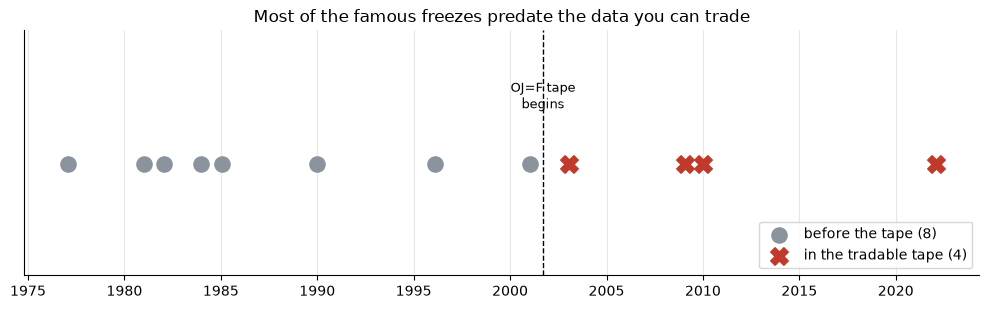

8 freezes before the tape, 4 inside it: [2003, 2009, 2010, 2022]


In [2]:
fz = data.freeze_dates()
if HAVE_REAL:
    f = load_oj(); start = f.index.min()
    in_tape = fz[(fz >= start) & (fz <= f.index.max())]
    pre = fz[fz < start]
else:
    start = pd.Timestamp('2001-09-17')
    in_tape = fz[fz >= start]; pre = fz[fz < start]
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.scatter(pre, [1]*len(pre), s=120, color=GREY, label=f'before the tape ({len(pre)})', zorder=3)
ax.scatter(in_tape, [1]*len(in_tape), s=160, color=RED, marker='X',
           label=f'in the tradable tape ({len(in_tape)})', zorder=4)
ax.axvline(start, ls='--', c='k', lw=1)
ax.annotate('OJ=F tape\nbegins', (start, 1.25), ha='center', fontsize=9)
ax.set_yticks([]); ax.set_ylim(0.5, 1.6); ax.legend(loc='lower right')
ax.set_title('Most of the famous freezes predate the data you can trade')
plt.tight_layout(); plt.show()
print(f'{len(pre)} freezes before the tape, {len(in_tape)} inside it: {list(in_tape.year)}')

There's the whole study in one chart. **8 of the 12 freezes** — including every dramatic 1980s freeze the legend is built on — happened **before** the OJ futures tape on Yahoo begins in 2001. The trade everyone remembers is literally untestable with the data a normal person can get.

**So what about the 4 freezes we *can* check?** Here's what OJ did over the week *after* each one (buying the first session after the freeze):

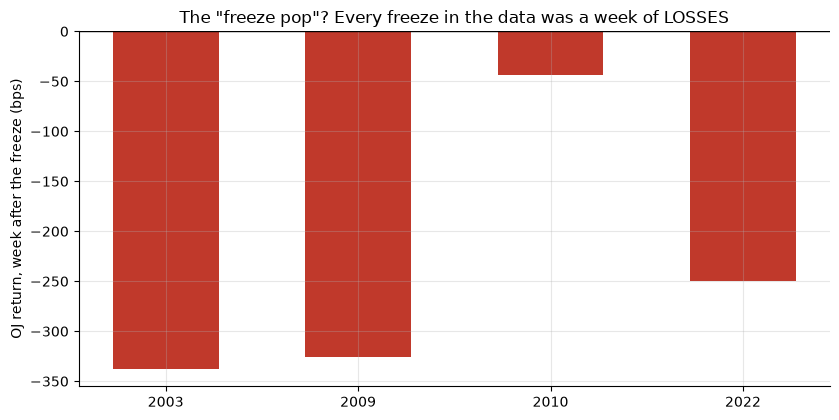

Per-freeze 5-day returns (bps): [-338, -326, -44, -250]


In [3]:
if HAVE_REAL:
    f = load_oj()
    led = st.window_returns(f, in_tape, window=5, lag=1)
    evs = [d.year for d in led['event_date']]
    rets = (led['ret_gross']*1e4).tolist()
else:
    evs = [2003, 2009, 2010, 2022]
    rets = [-338, -326, -44, -250]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
b = ax.bar([str(e) for e in evs], rets, color=[RED if r < 0 else GREEN for r in rets], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('OJ return, week after the freeze (bps)')
ax.set_title('The "freeze pop"? Every freeze in the data was a week of LOSSES')
plt.tight_layout(); plt.show()
print('Per-freeze 5-day returns (bps):', [round(r) for r in rets])

Four freezes, four losing weeks: **-338, -326, -44, -250 bps**. Not a single pop. The mean is about **-240 bps** — you'd have lost ~2.4% a week buying the freeze. The movie trade isn't just weak on this tape; it points the *wrong way*.

**Could it just be that OJ is strong in winter generally?** Here's Dec–Feb vs the rest of the year:

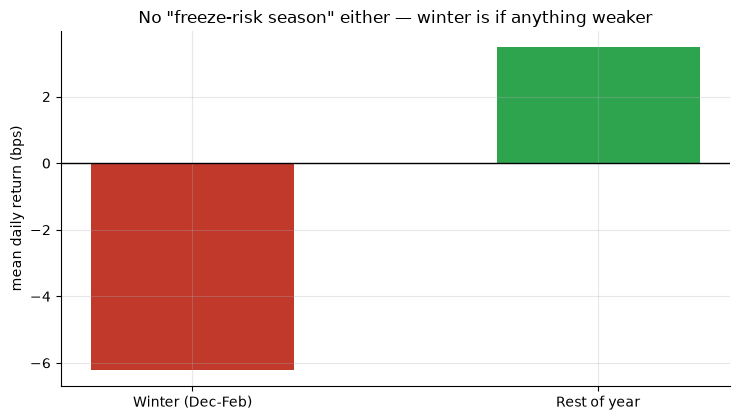

Winter -6.2 bps/day  vs  rest +3.5 bps/day


In [4]:
if HAVE_REAL:
    ws = st.winter_seasonality(load_oj())
    w, o = ws['winter_mean_bps'], ws['other_mean_bps']
else:
    w, o = -6.2, 3.5
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['Winter (Dec-Feb)', 'Rest of year'], [w, o],
       color=[RED if w < 0 else GREEN, GREEN if o > 0 else RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean daily return (bps)')
ax.set_title('No "freeze-risk season" either — winter is if anything weaker')
plt.tight_layout(); plt.show()
print(f'Winter {w:+.1f} bps/day  vs  rest {o:+.1f} bps/day')

Winter days average **-6.2 bps** vs **+3.5 bps** the rest of the year — the supposed freeze-risk season is actually a touch *worse*, and statistically it's a coin flip. No seasonal trade hiding here either.

## 5 · The verdict

- **Signal — None.** Only 4 freezes are in the tradable tape, and all four were losing weeks. Four events can't prove anything — and what little there is points the wrong way. Winter seasonality is a non-event too.
- **Tradability — Mirage.** Nothing to trade: the legendary freezes aren't in the data, the ones that are go the wrong way, and OJ futures are a tiny, wide-spread market on top of it.
- **The *Trading Places* trade? — Busted.** A wonderful movie premise and, on every freeze we can measure, a money-loser.

## 6 · Could you actually trade it?

There's no edge to charge costs against — but even if there *were*, the news is worse. The honest trade enters the day **after** the freeze. But maybe the pop happens *on* the freeze day and you just missed it? So let's give the trade a superpower it can't really have — perfect foresight, entering on the freeze session itself:

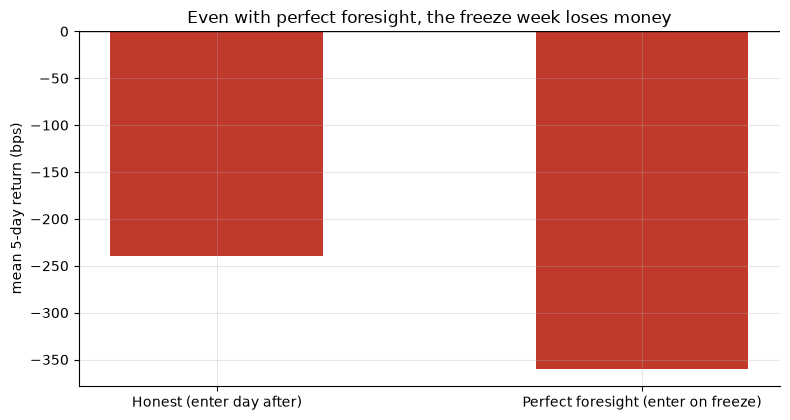

Honest lag: -240 bps   Perfect foresight: -360 bps


In [5]:
if HAVE_REAL:
    f = load_oj()
    m1 = st.summarize_events(st.window_returns(f, in_tape, window=5, lag=1), 'ret_gross')['mean_bps']
    m0 = st.summarize_events(st.window_returns(f, in_tape, window=5, lag=0), 'ret_gross')['mean_bps']
else:
    m1, m0 = -240, -360
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['Honest (enter day after)', 'Perfect foresight (enter on freeze)'], [m1, m0],
       color=[RED, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean 5-day return (bps)')
ax.set_title('Even with perfect foresight, the freeze week loses money')
plt.tight_layout(); plt.show()
print(f'Honest lag: {m1:+.0f} bps   Perfect foresight: {m0:+.0f} bps')

Even cheating — entering right on the freeze session — the week still averages **-360 bps**. The 'pop' isn't a move you were too slow to catch; on this tape it simply **isn't there**. There is no version of the trade, fast or slow, fair or not, that makes money.

## 7 · Going further 🚪

- **The data that built the legend is gone.** The honest fix would be a pre-2001 FCOJ series (the 1977/1981/1983/1985 freezes). If you have one, fork this and run the *real* *Trading Places* era — that's the only way to test the legend on its own turf.
- **Forecast-anticipation, not freeze-reaction.** Roll's signal is in the *forecast*, not the freeze. A version keyed to cold-snap *forecasts* (before the night) is a different, harder experiment.
- **Weather folklore in general.** See [Study 281 — El-Nino](../../281-el-nino/) for another weather-to-markets trade that didn't survive contact with the data.

*Think the freeze trade is real and we just have the wrong window? Fork this, change the window or the freeze list, and show OJ popping — on data you can actually pull.*